<a href="https://colab.research.google.com/github/9972610766preethi/Ai-Fashion-Designer.project/blob/main/AI_Fashion_Designer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q torch torchvision matplotlib numpy pillow tqdm


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# Project configuration
IMAGE_SIZE = 28
CHANNELS = 1
NUM_CLASSES = 10

LATENT_DIM = 100

BATCH_SIZE = 128
EPOCHS = 30

LEARNING_RATE = 0.0002
BETA1 = 0.5

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Configuration completed!")


Device: cuda
Configuration completed!


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Dataset size:", len(train_dataset))


100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 5.24MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


Dataset size: 60000


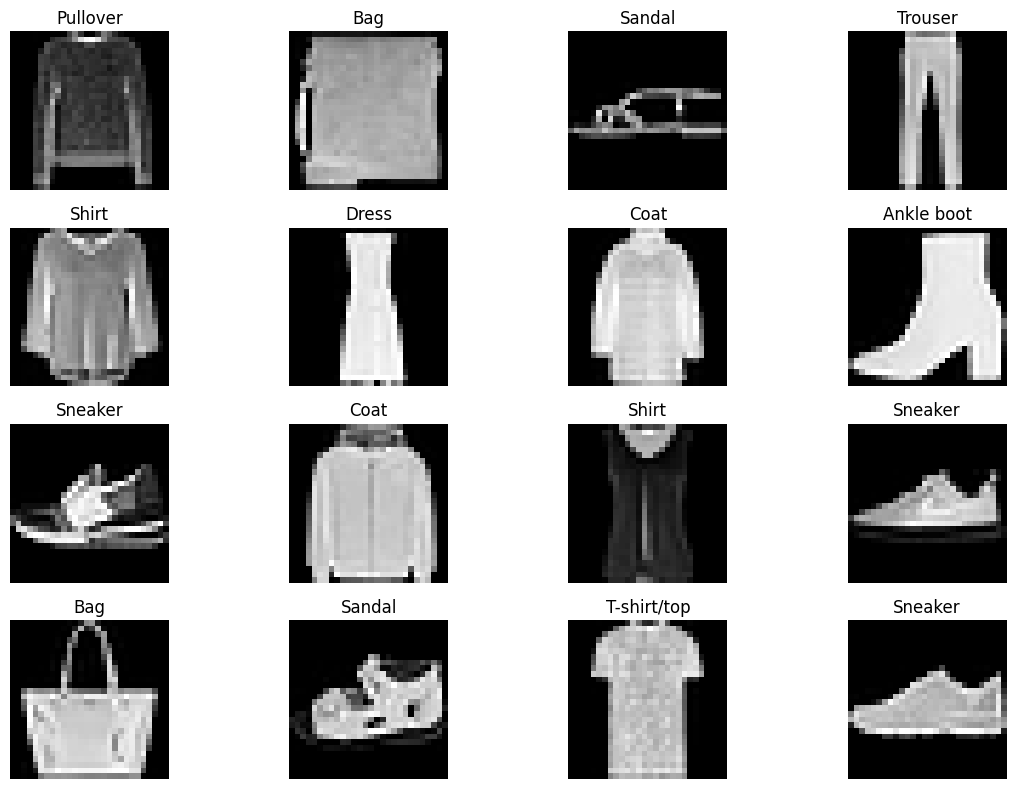

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    image = images[i].squeeze().numpy()
    image = (image + 1) / 2

    plt.imshow(image, cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
class Generator(nn.Module):

    def __init__(self, latent_dim=100, num_classes=10):
        super().__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            latent_dim
        )

        self.model = nn.Sequential(
            nn.Linear(latent_dim * 2, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),

            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(
                32, 1,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, noise, labels):

        label_vector = self.label_embedding(labels)

        x = torch.cat(
            [noise, label_vector],
            dim=1
        )

        return self.model(x)


In [ ]:
class Discriminator(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            28 * 28
        )

        self.model = nn.Sequential(
            nn.Linear(28 * 28 * 2, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, labels):

        image = image.view(image.size(0), -1)

        label_vector = self.label_embedding(labels)

        x = torch.cat(
            [image, label_vector],
            dim=1
        )

        return self.model(x)


In [ ]:
generator = Generator(
    latent_dim=LATENT_DIM,
    num_classes=NUM_CLASSES
).to(DEVICE)

discriminator = Discriminator(
    num_classes=NUM_CLASSES
).to(DEVICE)

print(generator)
print(discriminator)


Generator(
  (label_embedding): Embedding(10, 100)
  (model): Sequential(
    (0): Linear(in_features=200, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): Tanh()
  )
)
Discriminator(
  (label_embedding): Embedding(10, 784)
  (model): Sequential(
    (0): Linear(in_features=1568, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace

In [ ]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, 0.999)
)


In [ ]:
@torch.no_grad()
def generate_samples(epoch=None):

    generator.eval()

    noise = torch.randn(
        NUM_CLASSES,
        LATENT_DIM,
        device=DEVICE
    )

    labels = torch.arange(
        NUM_CLASSES,
        device=DEVICE
    )

    fake_images = generator(
        noise,
        labels
    )

    fake_images = (fake_images + 1) / 2

    grid = make_grid(
        fake_images,
        nrow=5,
        normalize=False
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(
        grid.permute(1, 2, 0).cpu().numpy().squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    title = "Generated Fashion Designs"

    if epoch is not None:
        title += f" — Epoch {epoch}"

    plt.title(title)
    plt.show()

    if epoch is not None:
        save_image(
            fake_images,
            f"outputs/epoch_{epoch}.png",
            nrow=5
        )

    generator.train()


Epoch 1/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: G Loss = 0.8362, D Loss = 1.3263


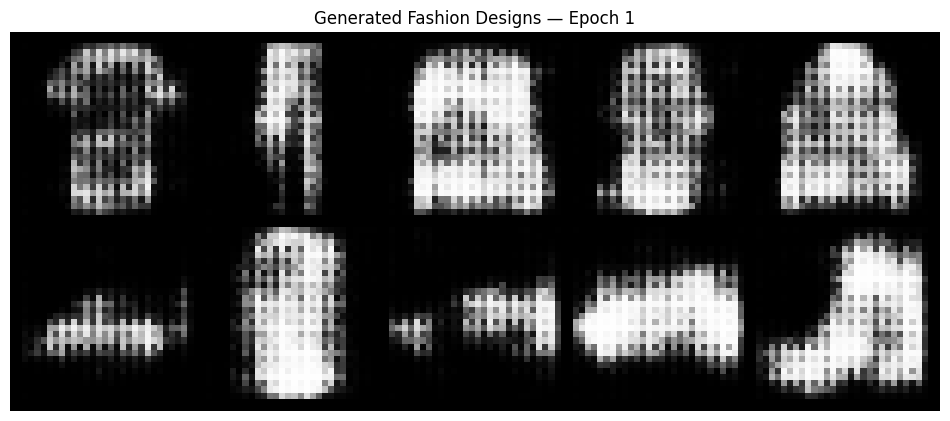

Epoch 2/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: G Loss = 0.7671, D Loss = 1.3641


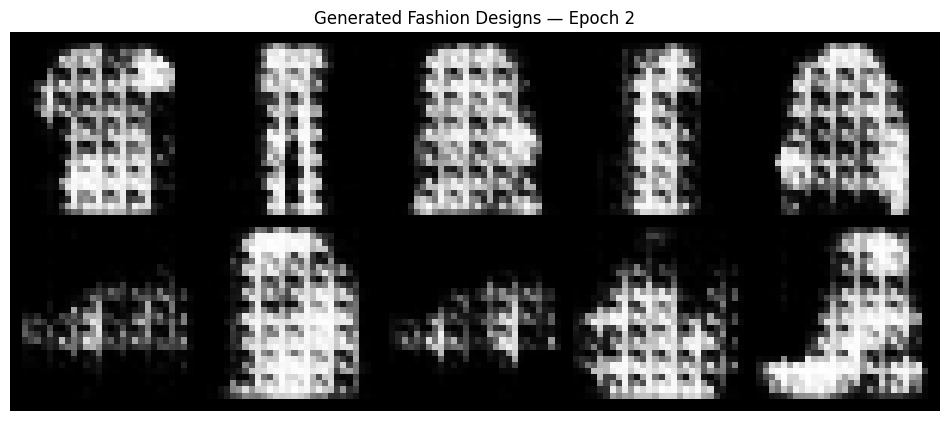

Epoch 3/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3: G Loss = 0.7881, D Loss = 1.3441


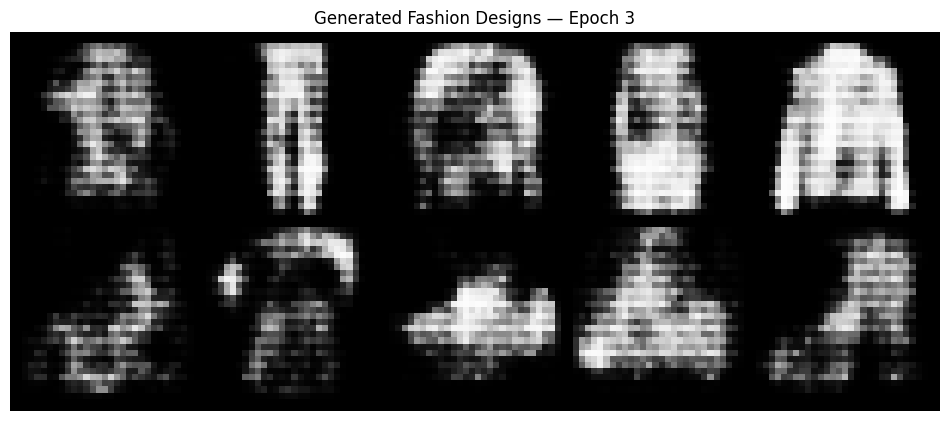

Epoch 4/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4: G Loss = 0.7759, D Loss = 1.3491


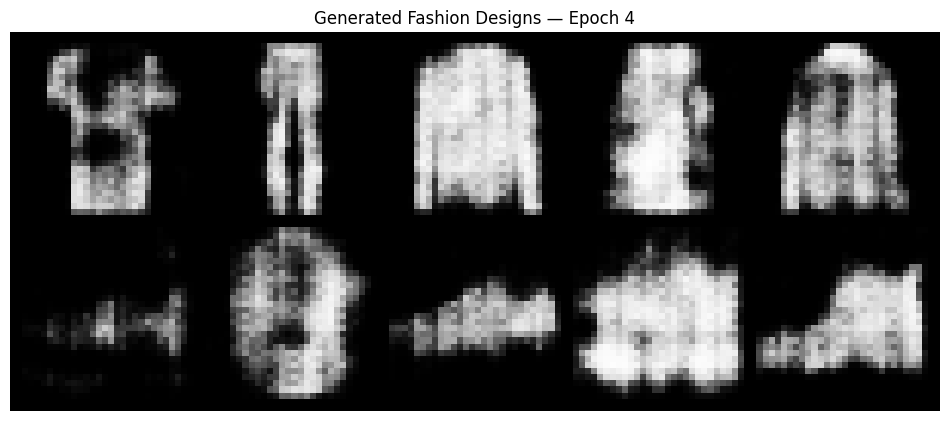

Epoch 5/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5: G Loss = 0.7569, D Loss = 1.3587


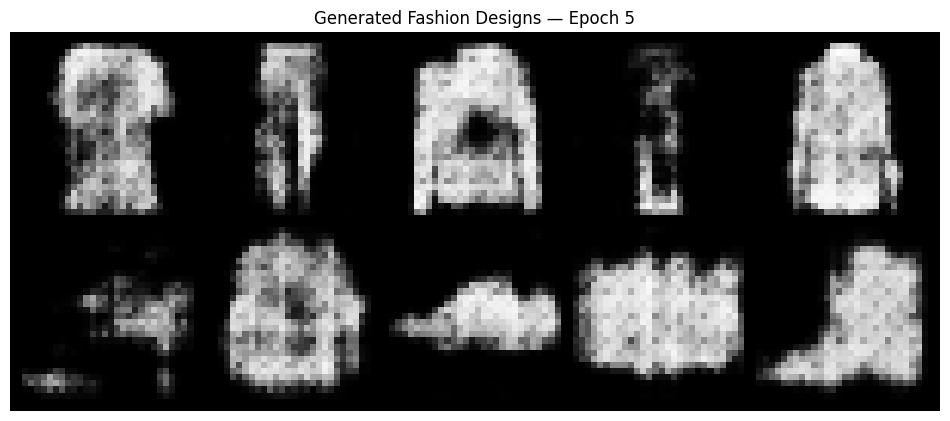

Epoch 6/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 6: G Loss = 0.7521, D Loss = 1.3613


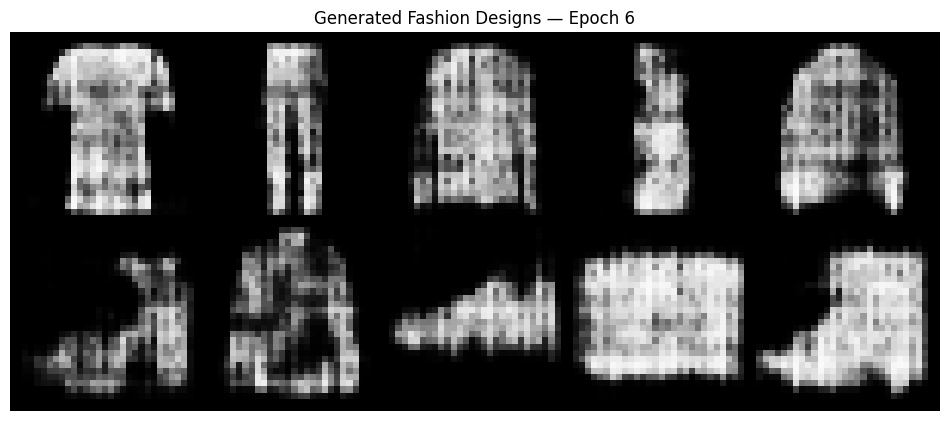

Epoch 7/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 7: G Loss = 0.7342, D Loss = 1.3715


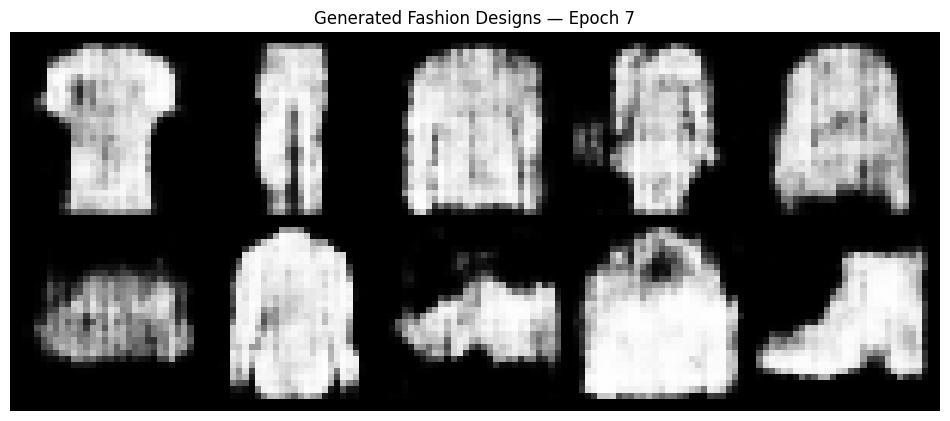

Epoch 8/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8: G Loss = 0.7187, D Loss = 1.3798


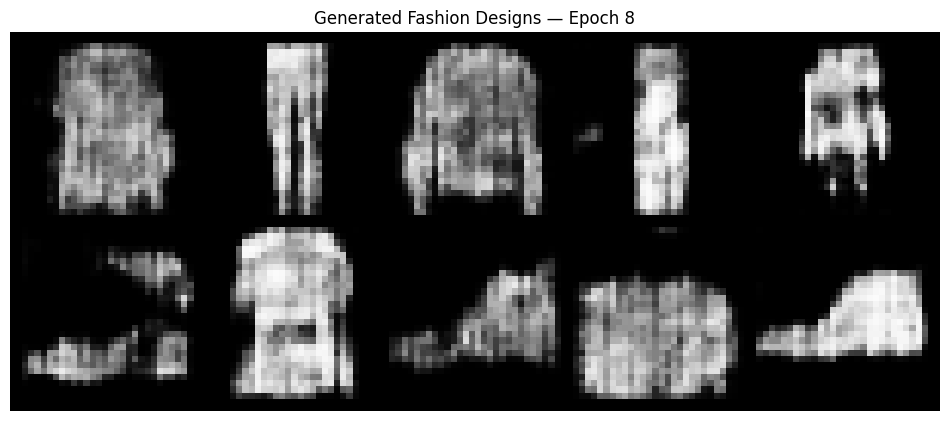

Epoch 9/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9: G Loss = 0.7153, D Loss = 1.3807


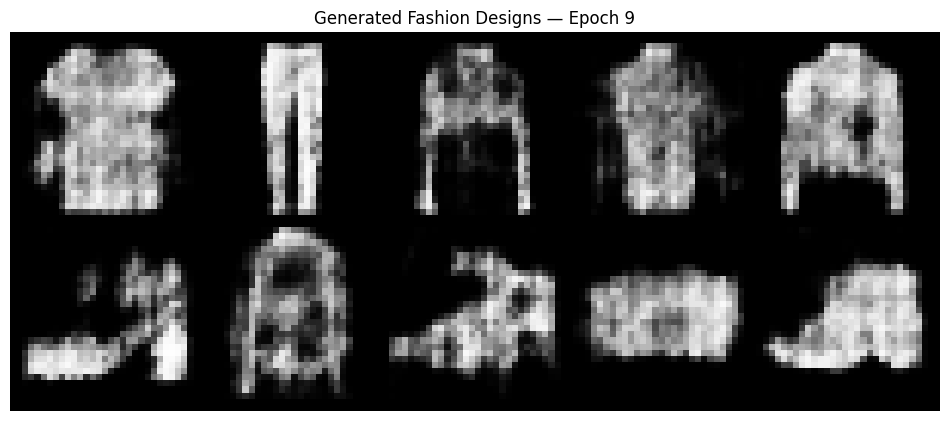

Epoch 10/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10: G Loss = 0.7104, D Loss = 1.3823


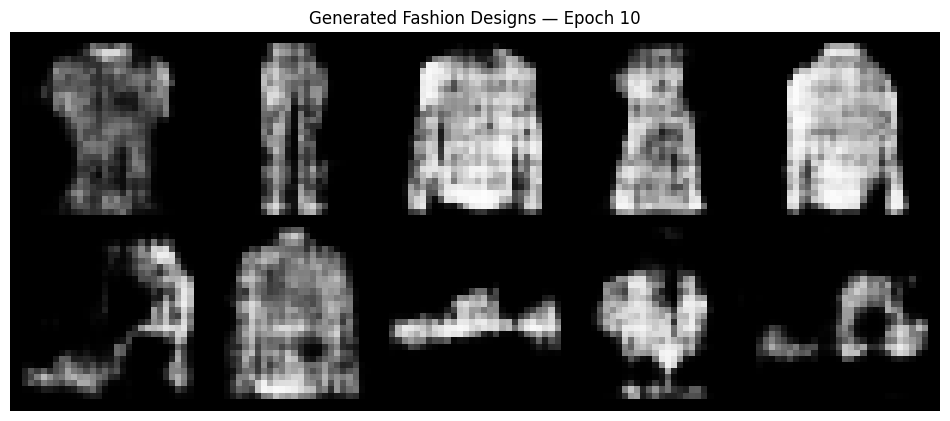

Epoch 11/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 11: G Loss = 0.7082, D Loss = 1.3836


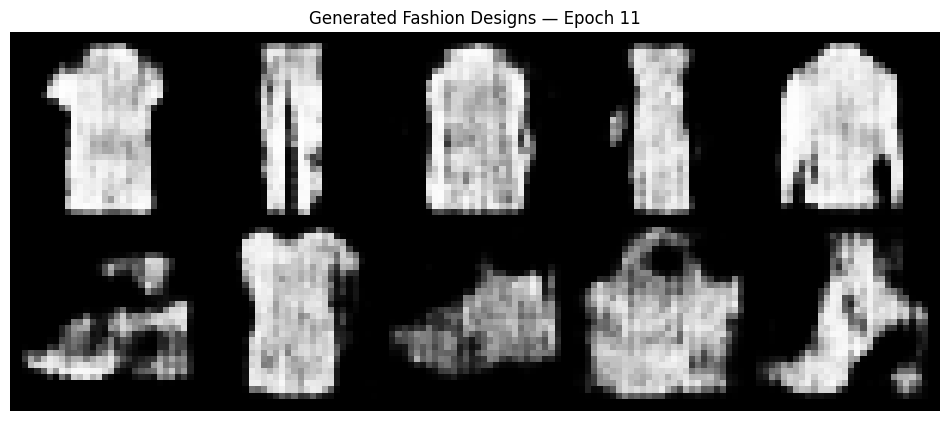

Epoch 12/30:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3c27ffa0c0>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3c27ffa0c0>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
if w.is_alive():    
self._shutdown_workers()  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python3.13/multiprocessing/process.py", line 1

Epoch 12: G Loss = 0.7076, D Loss = 1.3841


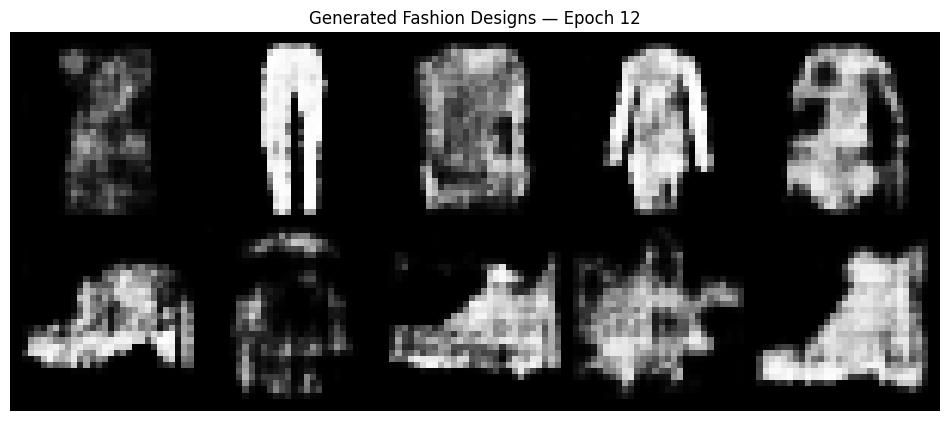

Epoch 13/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 13: G Loss = 0.7068, D Loss = 1.3851


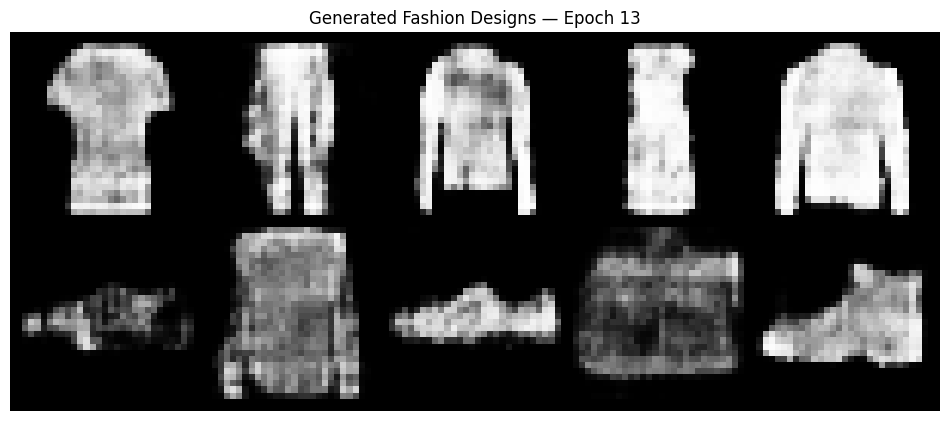

Epoch 14/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14: G Loss = 0.7034, D Loss = 1.3850


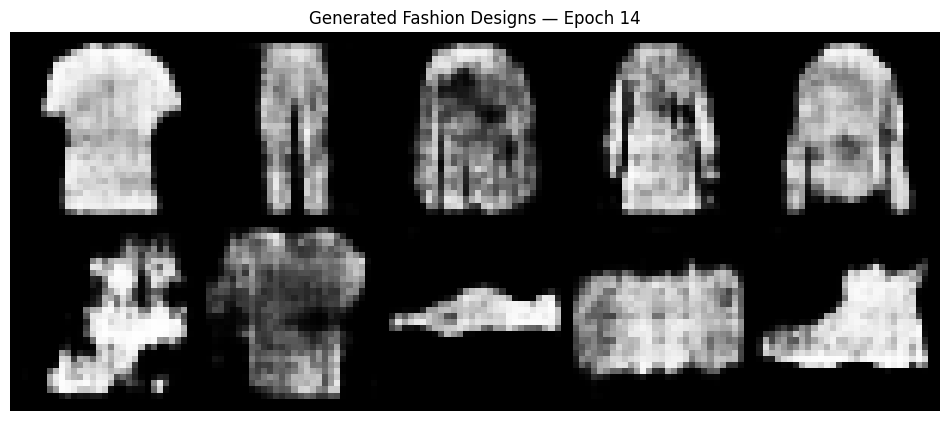

Epoch 15/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15: G Loss = 0.7014, D Loss = 1.3855


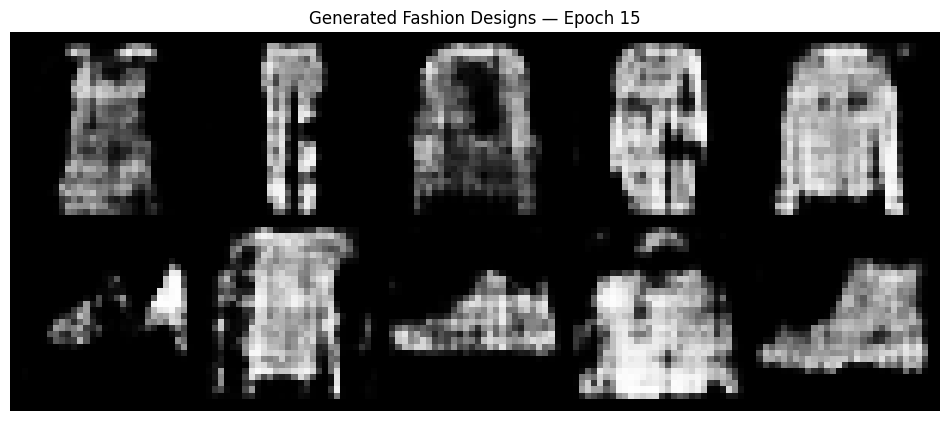

Epoch 16/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 16: G Loss = 0.7014, D Loss = 1.3859


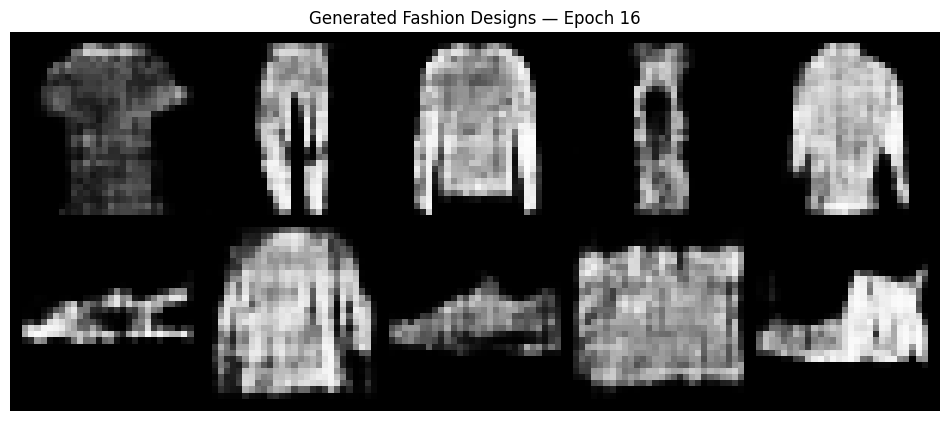

Epoch 17/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 17: G Loss = 0.6996, D Loss = 1.3856


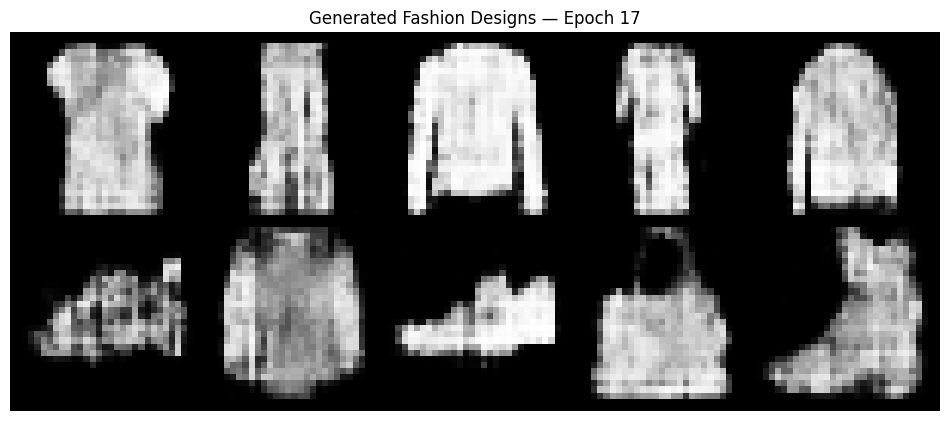

Epoch 18/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 18: G Loss = 0.7002, D Loss = 1.3863


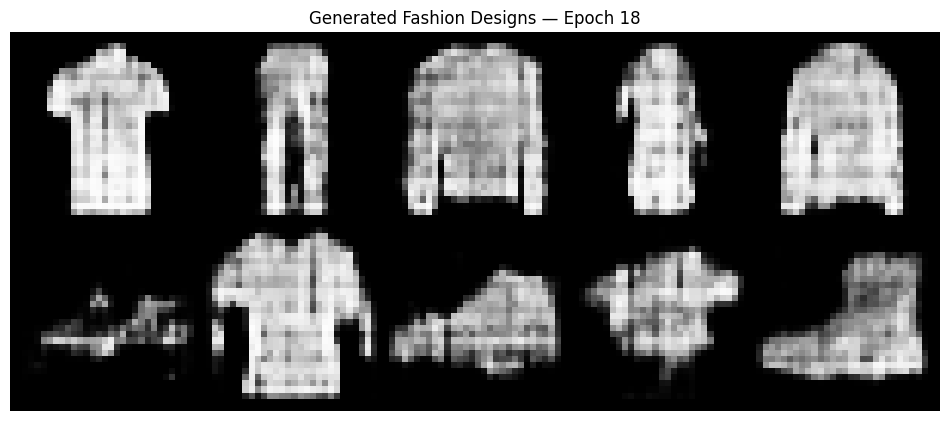

Epoch 19/30:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3c27ffa0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3c27ffa0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 19: G Loss = 0.6979, D Loss = 1.3862


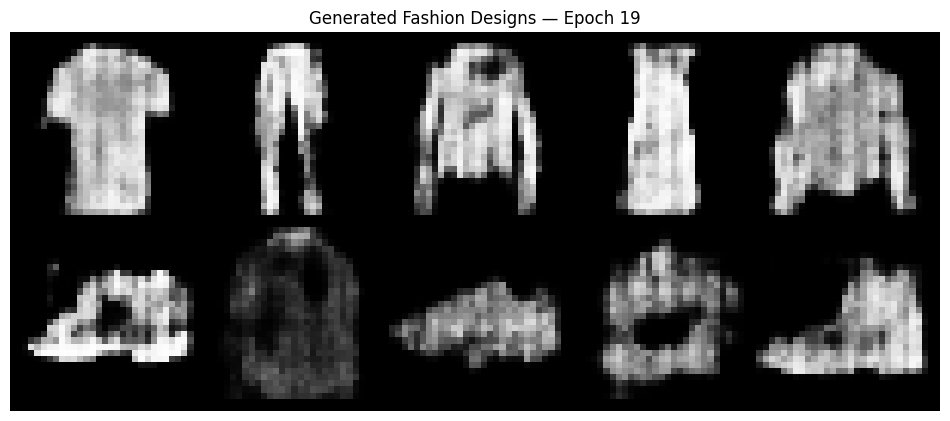

Epoch 20/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20: G Loss = 0.6979, D Loss = 1.3859


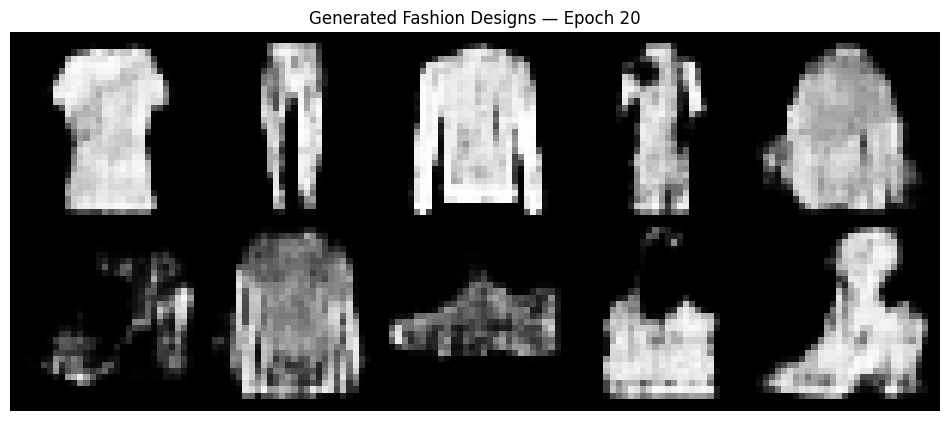

Epoch 21/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 21: G Loss = 0.6977, D Loss = 1.3865


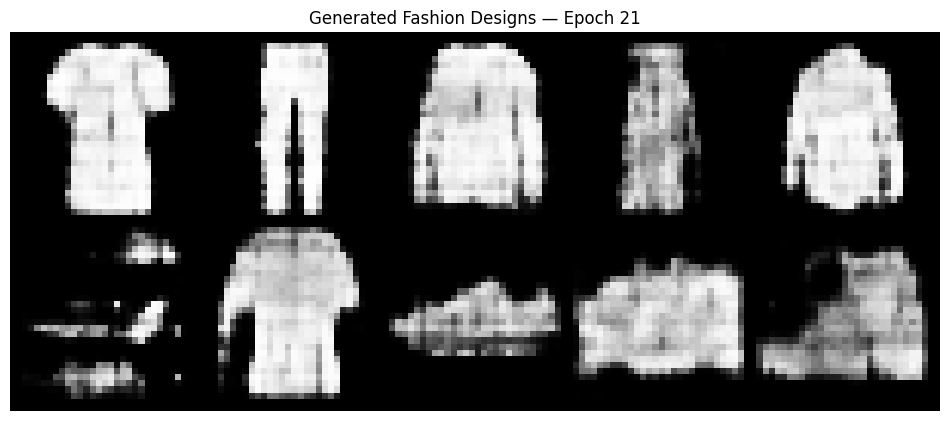

Epoch 22/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 22: G Loss = 0.6977, D Loss = 1.3863


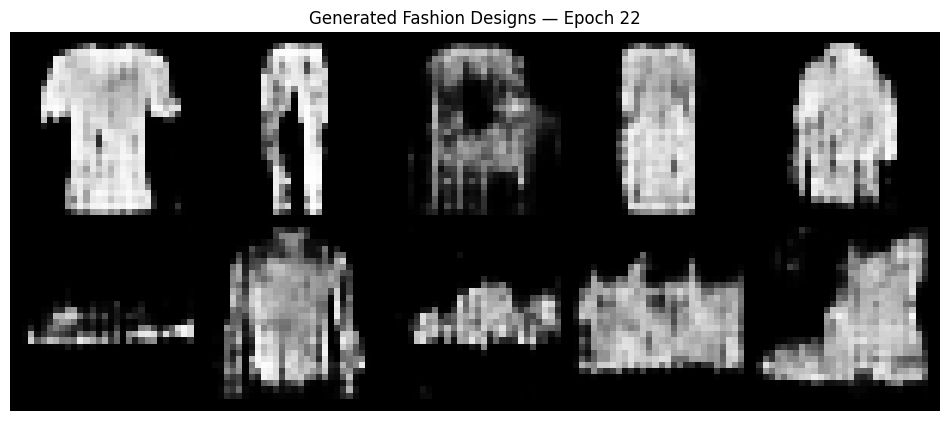

Epoch 23/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 23: G Loss = 0.6962, D Loss = 1.3863


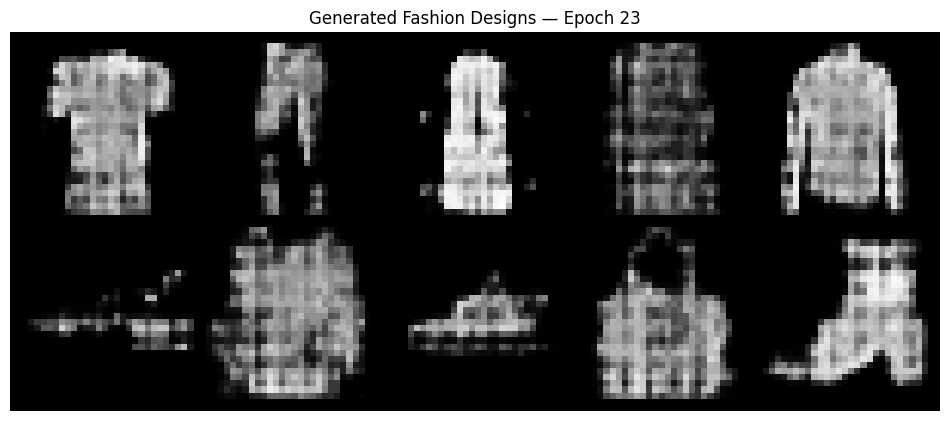

Epoch 24/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 24: G Loss = 0.6973, D Loss = 1.3865


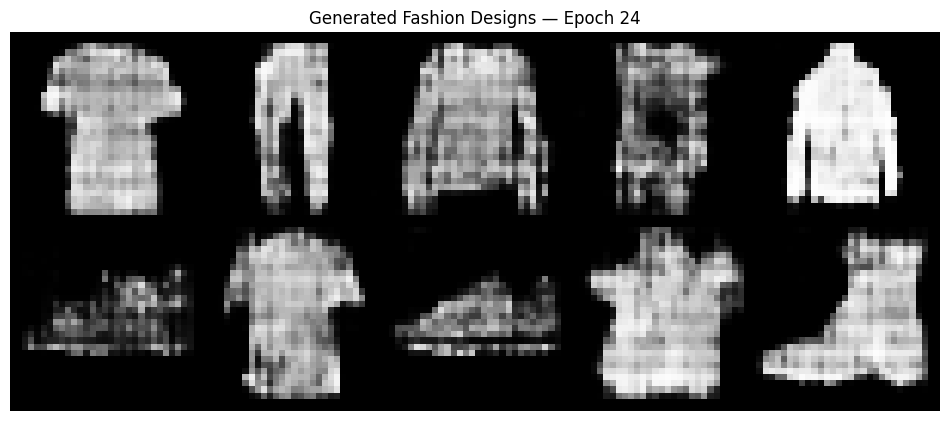

Epoch 25/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 25: G Loss = 0.6980, D Loss = 1.3863


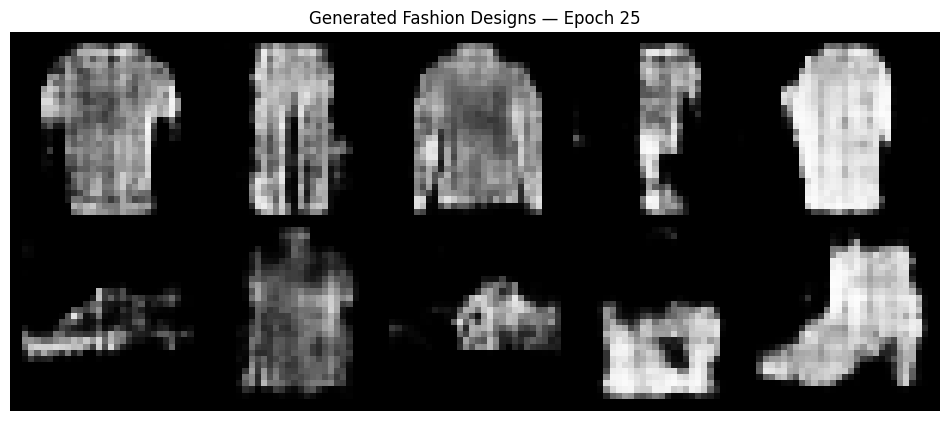

Epoch 26/30:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3c27ffa0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3c27ffa0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _Multi

Epoch 26: G Loss = 0.6965, D Loss = 1.3864


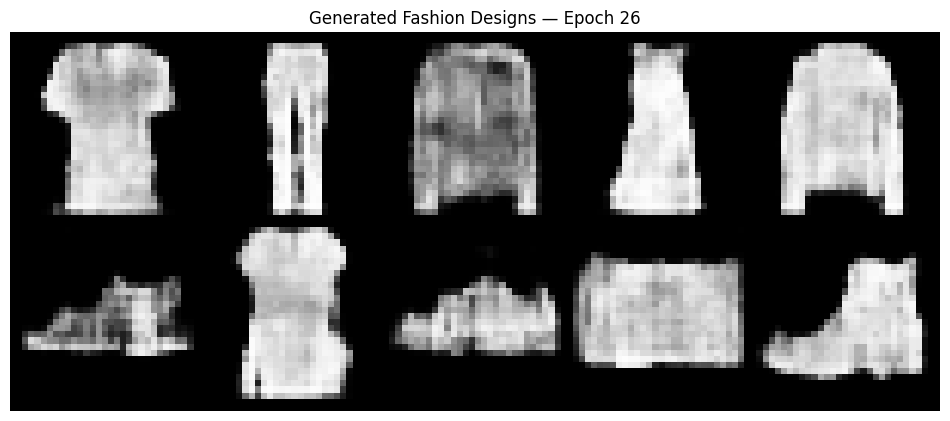

Epoch 27/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 27: G Loss = 0.6966, D Loss = 1.3866


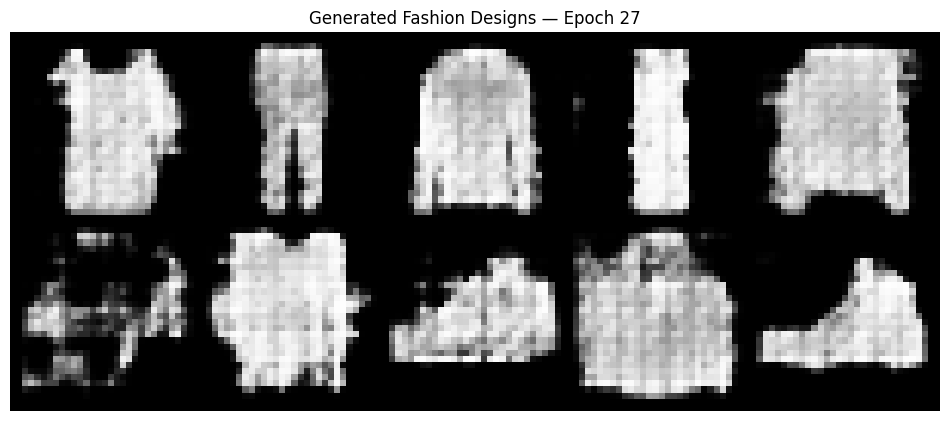

Epoch 28/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 28: G Loss = 0.6964, D Loss = 1.3864


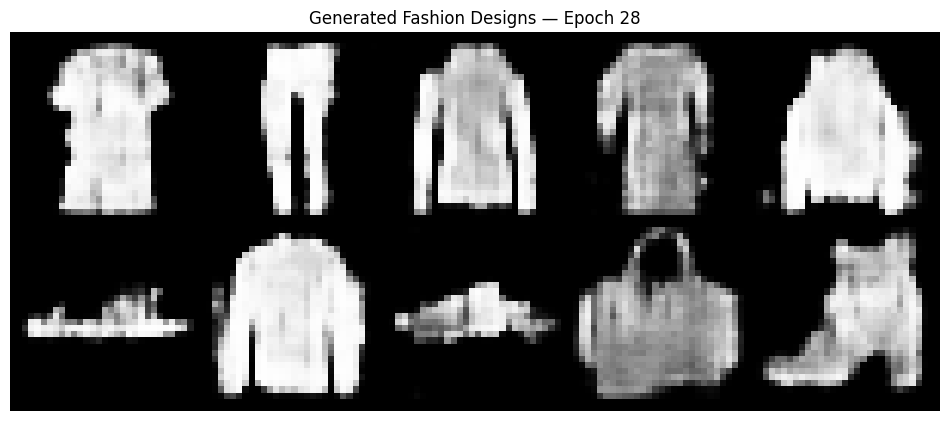

Epoch 29/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 29: G Loss = 0.6961, D Loss = 1.3865


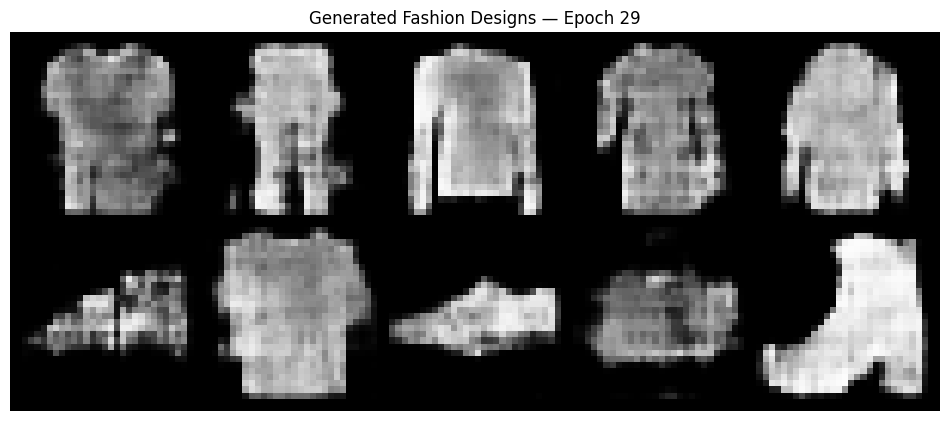

Epoch 30/30:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 30: G Loss = 0.6956, D Loss = 1.3867


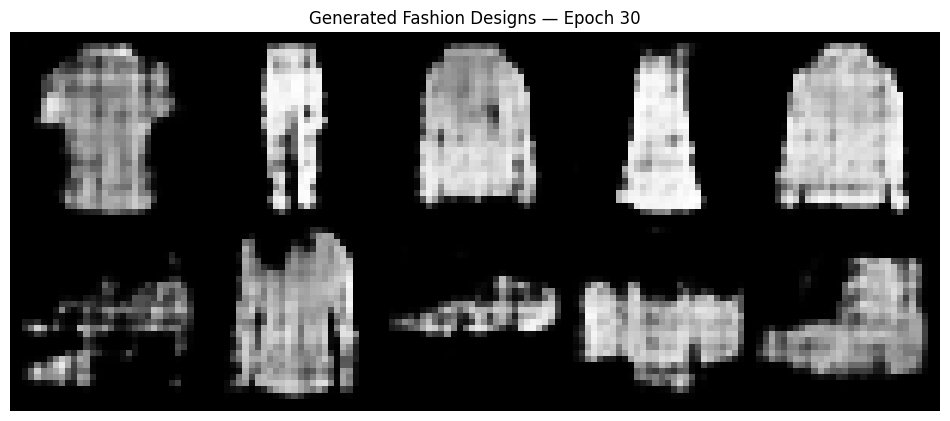

In [ ]:
G_losses = []
D_losses = []

for epoch in range(1, EPOCHS + 1):

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS}"
    )

    epoch_g_loss = 0
    epoch_d_loss = 0

    for real_images, real_labels in progress_bar:

        real_images = real_images.to(DEVICE)
        real_labels = real_labels.to(DEVICE)

        batch_size = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------

        optimizer_D.zero_grad()

        real_target = torch.ones(
            batch_size,
            1,
            device=DEVICE
        )

        fake_target = torch.zeros(
            batch_size,
            1,
            device=DEVICE
        )

        real_output = discriminator(
            real_images,
            real_labels
        )

        real_loss = criterion(
            real_output,
            real_target
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=DEVICE
        )

        fake_labels = torch.randint(
            0,
            NUM_CLASSES,
            (batch_size,),
            device=DEVICE
        )

        fake_images = generator(
            noise,
            fake_labels
        )

        fake_output = discriminator(
            fake_images.detach(),
            fake_labels
        )

        fake_loss = criterion(
            fake_output,
            fake_target
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=DEVICE
        )

        fake_labels = torch.randint(
            0,
            NUM_CLASSES,
            (batch_size,),
            device=DEVICE
        )

        generated_images = generator(
            noise,
            fake_labels
        )

        output = discriminator(
            generated_images,
            fake_labels
        )

        g_loss = criterion(
            output,
            real_target
        )

        g_loss.backward()
        optimizer_G.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

        progress_bar.set_postfix({
            "D Loss": f"{d_loss.item():.4f}",
            "G Loss": f"{g_loss.item():.4f}"
        })

    avg_g = epoch_g_loss / len(train_loader)
    avg_d = epoch_d_loss / len(train_loader)

    G_losses.append(avg_g)
    D_losses.append(avg_d)

    print(
        f"Epoch {epoch}: "
        f"G Loss = {avg_g:.4f}, "
        f"D Loss = {avg_d:.4f}"
    )

    generate_samples(epoch)


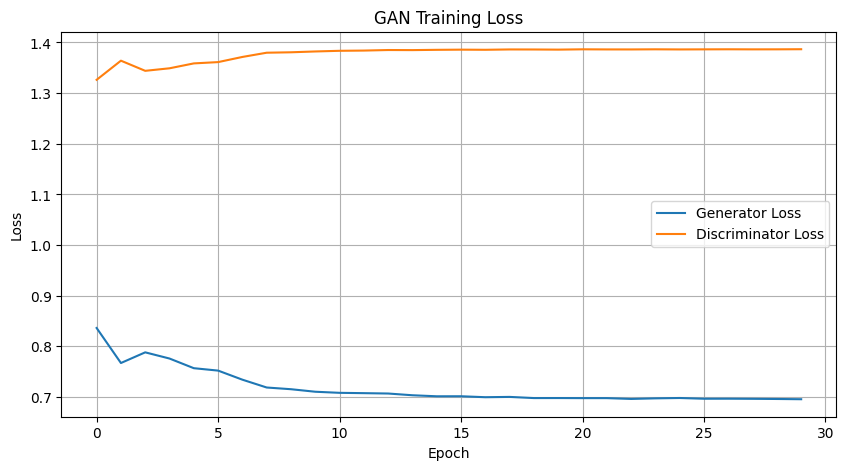

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    G_losses,
    label="Generator Loss"
)

plt.plot(
    D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")

plt.legend()
plt.grid()

plt.show()


In [ ]:
def generate_fashion(category, number=8):

    generator.eval()

    category_id = class_names.index(category)

    noise = torch.randn(
        number,
        LATENT_DIM,
        device=DEVICE
    )

    labels = torch.full(
        (number,),
        category_id,
        dtype=torch.long,
        device=DEVICE
    )

    with torch.no_grad():

        images = generator(
            noise,
            labels
        )

    images = (images + 1) / 2

    grid = make_grid(
        images,
        nrow=4
    )

    plt.figure(figsize=(10, 6))

    plt.imshow(
        grid.permute(1, 2, 0).cpu().numpy().squeeze(),
        cmap="gray"
    )

    plt.title(
        f"AI Generated: {category}"
    )

    plt.axis("off")
    plt.show()

    generator.train()

    return images


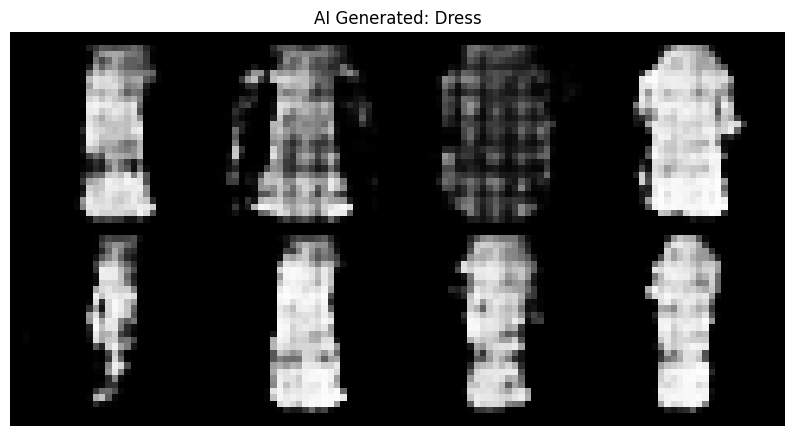

In [ ]:
images = generate_fashion(
    "Dress",
    number=8
)


In [ ]:
torch.save(
    generator.state_dict(),
    "models/fashion_generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "models/fashion_discriminator.pth"
)

print("Models saved successfully!")


Models saved successfully!


In [ ]:
from google.colab import files

files.download(
    "models/fashion_generator.pth"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    "models/fashion_discriminator.pth"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

category_dropdown = widgets.Dropdown(
    options=class_names,
    description="Fashion:"
)

number_slider = widgets.IntSlider(
    value=8,
    min=1,
    max=16,
    step=1,
    description="Designs:"
)

generate_button = widgets.Button(
    description="Generate Designs",
    button_style="success"
)

output = widgets.Output()


def on_generate_clicked(button):

    with output:

        clear_output()

        generate_fashion(
            category_dropdown.value,
            number_slider.value
        )


generate_button.on_click(
    on_generate_clicked
)

display(
    category_dropdown,
    number_slider,
    generate_button,
    output
)


Dropdown(description='Fashion:', options=('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Sh…

IntSlider(value=8, description='Designs:', max=16, min=1)

Button(button_style='success', description='Generate Designs', style=ButtonStyle())

Output()

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/AI_Fashion_Designer"

os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(
    f"{PROJECT_PATH}/models",
    exist_ok=True
)
os.makedirs(
    f"{PROJECT_PATH}/outputs",
    exist_ok=True
)

print("Project folder:", PROJECT_PATH)


Project folder: /content/drive/MyDrive/AI_Fashion_Designer
